In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import prince
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from src.utils.config import (
    EDA_OUTPUT_PARAMS_PATH,
    FE_OUTPUT_PARAMS_PATH,
    TRAINING_OUTPUT_PLOTS_PATH,
    FE_OUTPUT_SCALER_PATH,
)
from src.data.processed_data import get_fe_weighted_data
from src.data.processed_data import get_fe_ohe_data
from src.data.processed_data import get_validated_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
from src.visualization.plots import make_plot
from src.visualization.plots import multiple_scatterplot
from kmodes.kprototypes import KPrototypes

In [3]:
# Add load params at processed_data... and change name...
weighted_data = get_fe_weighted_data()
ohe_data = get_fe_ohe_data()
validated_data = get_validated_data()
validated_data = validated_data[['price', 'recommendations']]
discrete_columns = pd.DataFrame(validated_data['price'] == 0)
discrete_columns['recommendations'] = validated_data['recommendations'] > 100

with open(EDA_OUTPUT_PARAMS_PATH, "r", encoding="utf-8") as file:
    eda_output = json.load(file)
with open(FE_OUTPUT_PARAMS_PATH, 'r', encoding="utf-8") as file:
    fe_output = json.load(file)

# First Model Analysis and Training
- Weighted genres and categories
- K-means model

# Second Model Analysis and Training
- Encoded (OHE) genres and categories
- K-Prototypes model

# Data PCA Visualizations

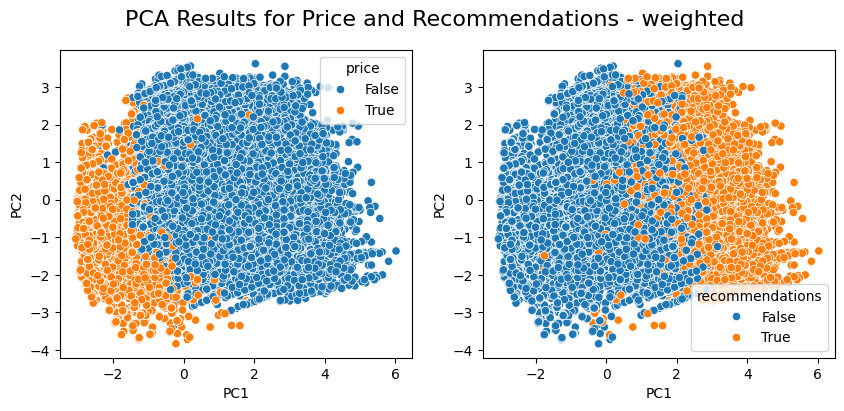

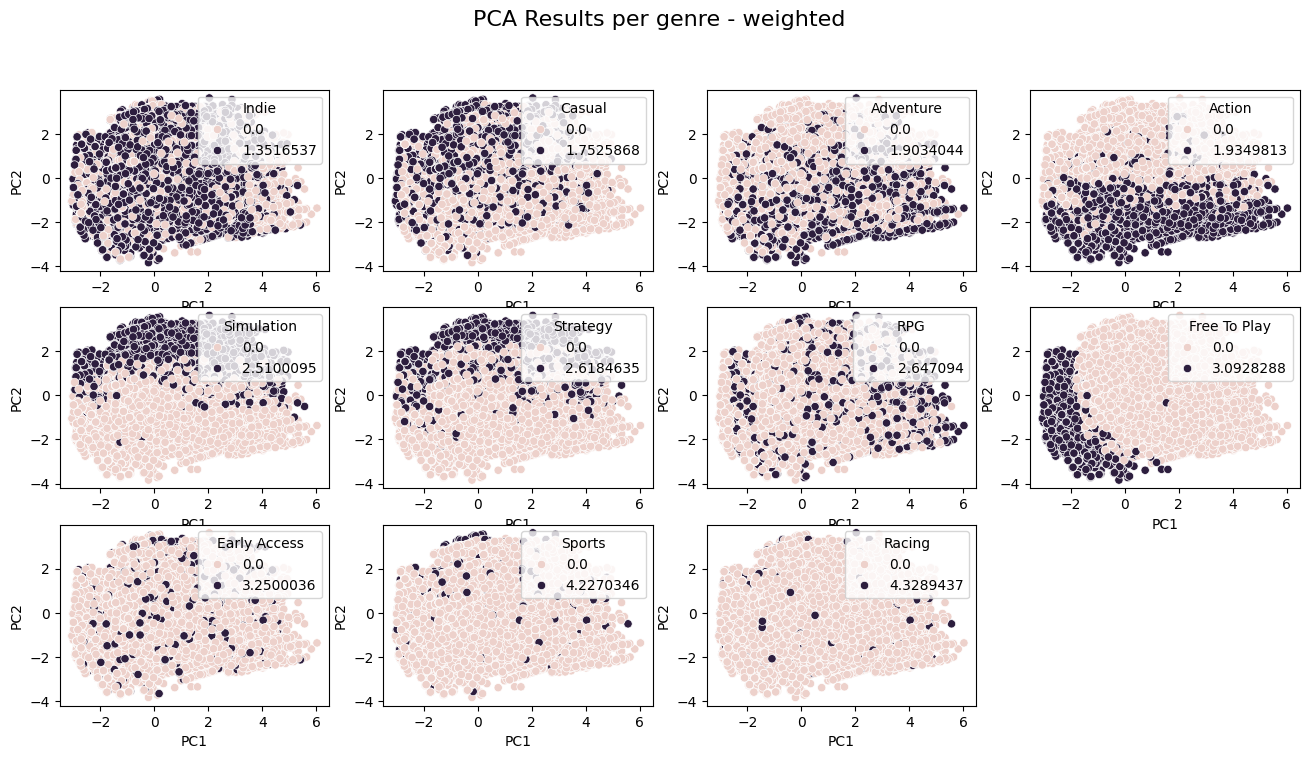

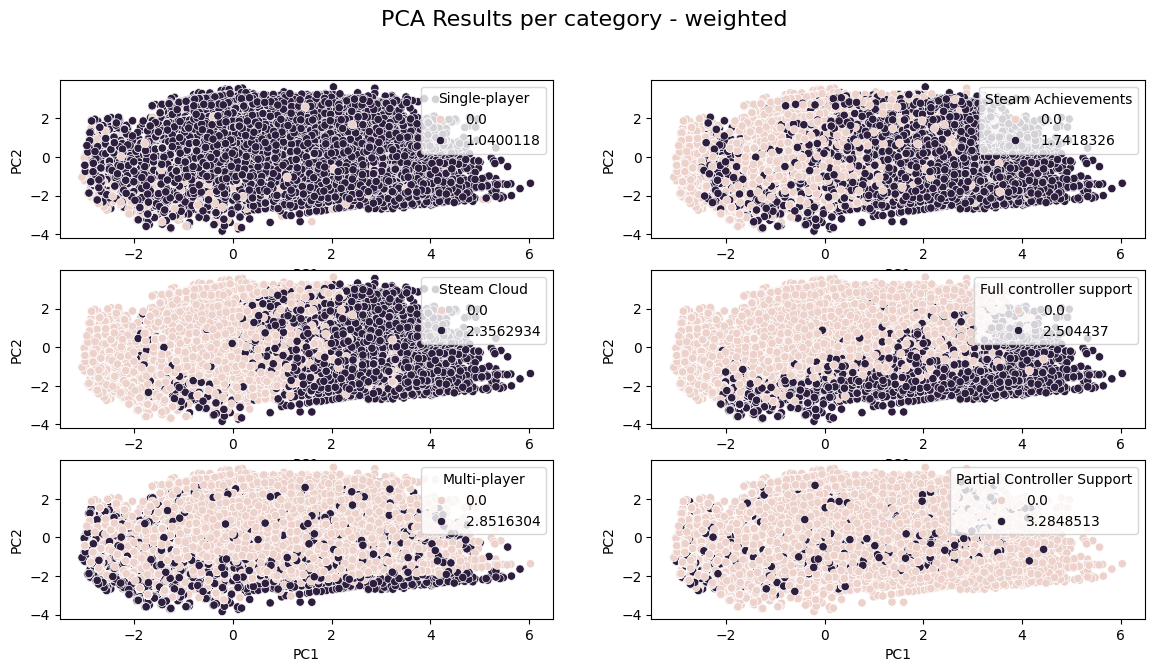

In [4]:
# PCA visualization - weighted
weighted_pca = PCA(n_components=10)
weighted_pca_trained = weighted_pca.fit_transform(weighted_data)
weighted_trained_pca_df = pd.DataFrame(weighted_pca_trained[:, :3], columns=["PC1", "PC2", "PC3"])
genres = weighted_data[fe_output['genres']].reset_index(drop=True)
categories = weighted_data[fe_output['categories']].reset_index(drop=True)

multiple_scatterplot(
    data=weighted_trained_pca_df,
    title="PCA Results for Price and Recommendations - weighted",
    x_col="PC1",
    y_col="PC2",
    n=1,
    m=2,
    hue_values=discrete_columns,
    xsize=10,
    ysize=4,
)
multiple_scatterplot(
    data=weighted_trained_pca_df,
    title="PCA Results per genre - weighted",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=4,
    hue_values=genres,
    xsize=16,
    ysize=8,
)
multiple_scatterplot(
    data=weighted_trained_pca_df,
    title="PCA Results per category - weighted",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=2,
    hue_values=categories,
    xsize=14,
    ysize=7,
)

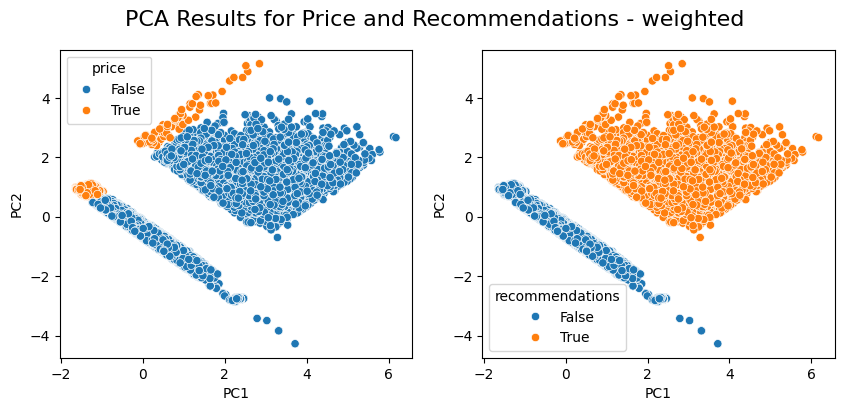

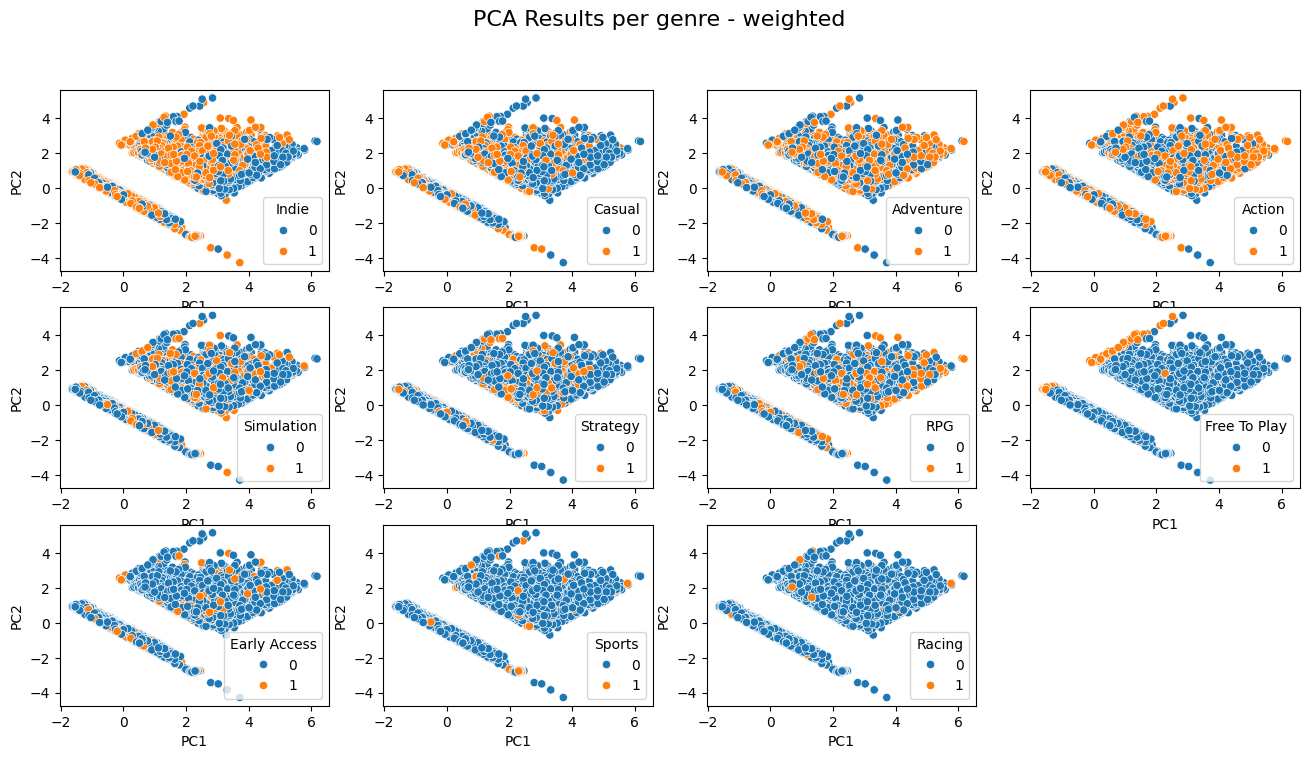

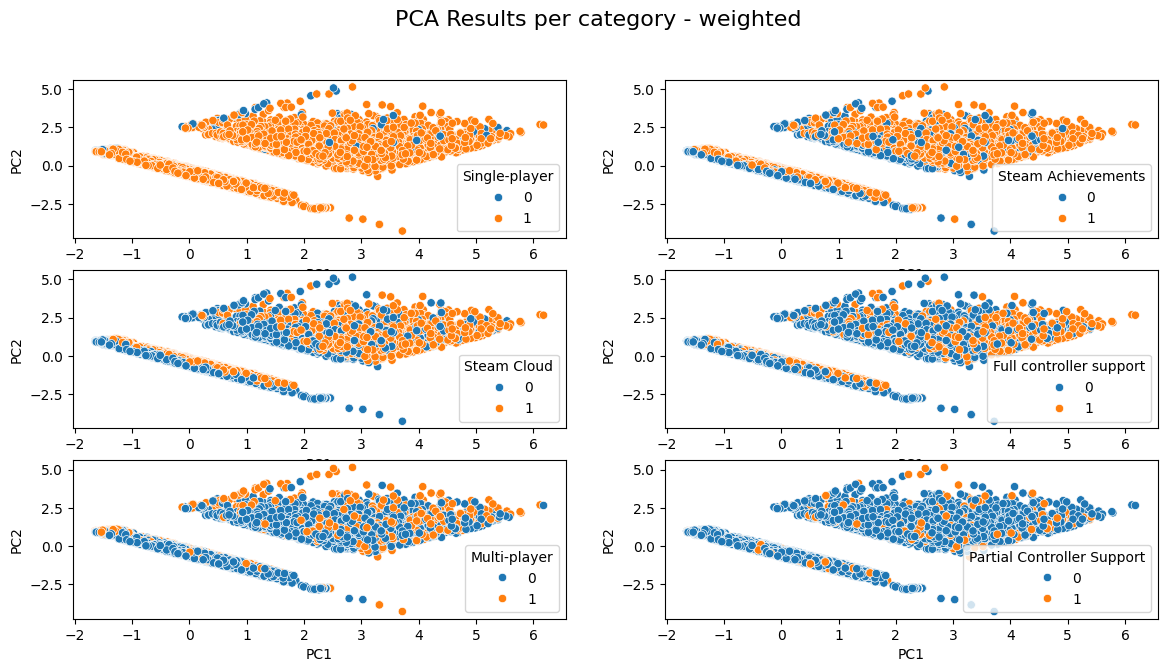

In [5]:
# PCA visualization - weighted
ohe_pca = PCA(n_components=10)
ohe_pca_trained = ohe_pca.fit_transform(ohe_data)
ohe_trained_pca_df = pd.DataFrame(ohe_pca_trained[:, :3], columns=["PC1", "PC2", "PC3"])
genres = ohe_data[fe_output['genres']].reset_index(drop=True)
categories = ohe_data[fe_output['categories']].reset_index(drop=True)

multiple_scatterplot(
    data=ohe_trained_pca_df,
    title="PCA Results for Price and Recommendations - weighted",
    x_col="PC1",
    y_col="PC2",
    n=1,
    m=2,
    hue_values=discrete_columns,
    xsize=10,
    ysize=4,
)
multiple_scatterplot(
    data=ohe_trained_pca_df,
    title="PCA Results per genre - weighted",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=4,
    hue_values=genres,
    xsize=16,
    ysize=8,
)
multiple_scatterplot(
    data=ohe_trained_pca_df,
    title="PCA Results per category - weighted",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=2,
    hue_values=categories,
    xsize=14,
    ysize=7,
)

# Test variance to define optimal Centroids

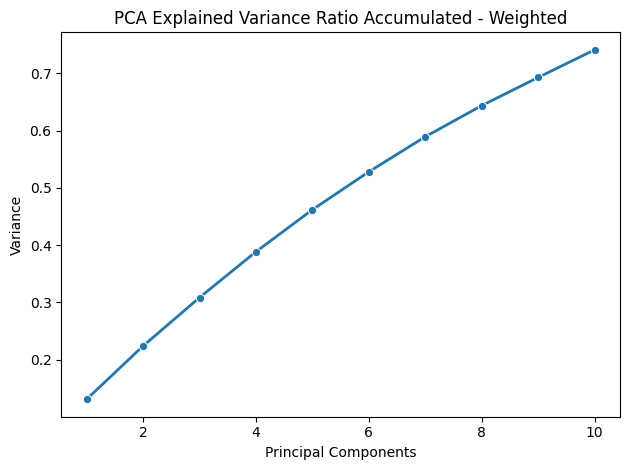

Total variance explained by PC1+PC2+PC3: 0.30852282
Variance explained by each Principal Component: [0.13096902 0.09305187 0.08450194 0.08002494 0.07327636 0.06621873
 0.06118968 0.05434614 0.04913573 0.04821097]
Accumulated Variance: [0.13096902 0.2240209  0.30852282 0.38854775 0.46182412 0.52804285
 0.5892325  0.64357865 0.6927144  0.7409254 ]


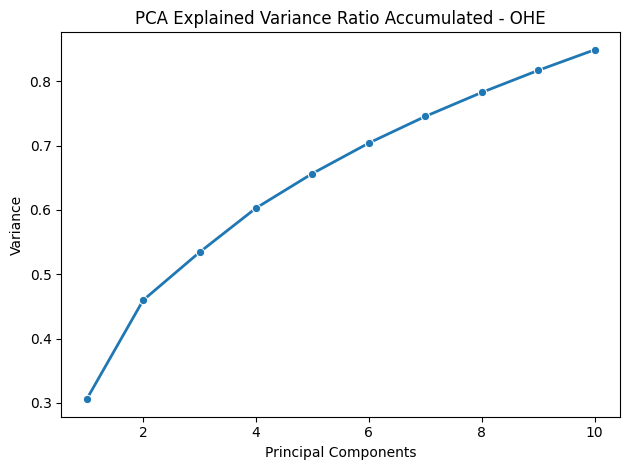

Total variance explained by PC1+PC2+PC3: 0.5341599
Variance explained by each Principal Component: [0.3058244  0.15380432 0.07453123 0.06860641 0.05373871 0.04732885
 0.04136658 0.03721466 0.03425194 0.03198615]
Accumulated Variance: [0.3058244  0.4596287  0.5341599  0.6027663  0.656505   0.7038338
 0.7452004  0.78241503 0.81666696 0.84865314]


In [6]:
# Visualice accumulated variance ratio - weighted
make_plot(
    plot_type="line",
    data=None,
    x_col=np.arange(1, 11),
    y_col=weighted_pca.explained_variance_ratio_.cumsum(),
    title='PCA Explained Variance Ratio Accumulated - Weighted',
    xlabel="Principal Components",
    ylabel="Variance",
)
plt.show()

print(
    "Total variance explained by PC1+PC2+PC3:", weighted_pca.explained_variance_ratio_[:3].sum()
)
print("Variance explained by each Principal Component:", weighted_pca.explained_variance_ratio_)
print("Accumulated Variance:", weighted_pca.explained_variance_ratio_.cumsum())

# Visualice accumulated variance ratio - ohe
make_plot(
    plot_type="line",
    data=None,
    x_col=np.arange(1, 11),
    y_col=ohe_pca.explained_variance_ratio_.cumsum(),
    title='PCA Explained Variance Ratio Accumulated - OHE',
    xlabel="Principal Components",
    ylabel="Variance",
)
plt.show()

print(
    "Total variance explained by PC1+PC2+PC3:", ohe_pca.explained_variance_ratio_[:3].sum()
)
print("Variance explained by each Principal Component:", ohe_pca.explained_variance_ratio_)
print("Accumulated Variance:", ohe_pca.explained_variance_ratio_.cumsum())

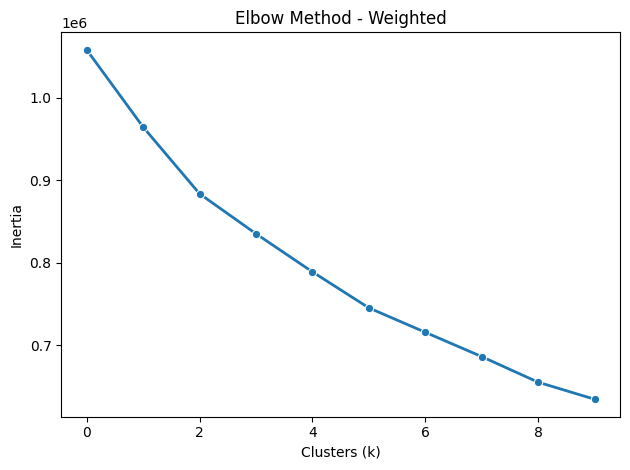

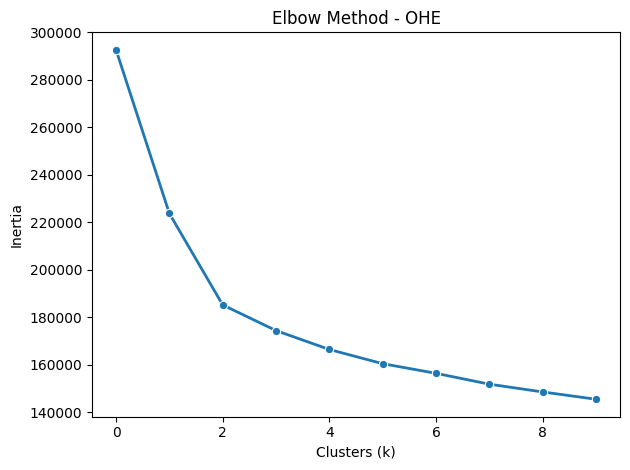

In [7]:
# Visualice elbow method on inertias - Weighted 
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(weighted_data)
    inertias.append(km.inertia_)

make_plot(
    plot_type="line",
    data=inertias,
    x_col=None,
    y_col=None,
    title='Elbow Method - Weighted',
    xlabel="Clusters (k)",
    ylabel="Inertia",
    xticks=k_range,
)
plt.show()

# Visualice elbow method on inertias - ohe 
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(ohe_data)
    inertias.append(km.inertia_)

make_plot(
    plot_type="line",
    data=inertias,
    x_col=None,
    y_col=None,
    title='Elbow Method - OHE',
    xlabel="Clusters (k)",
    ylabel="Inertia",
    xticks=k_range,
)
plt.show()

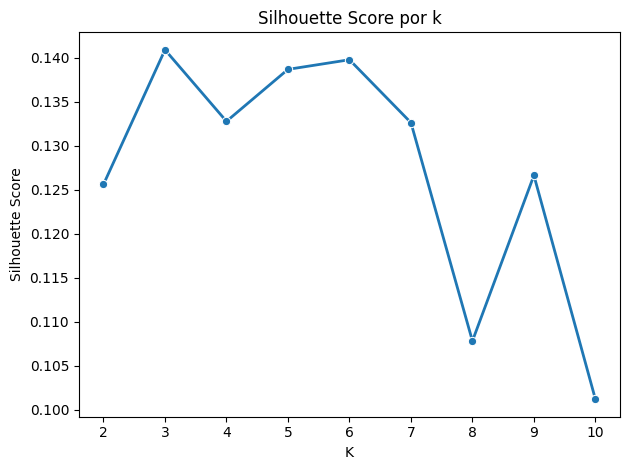

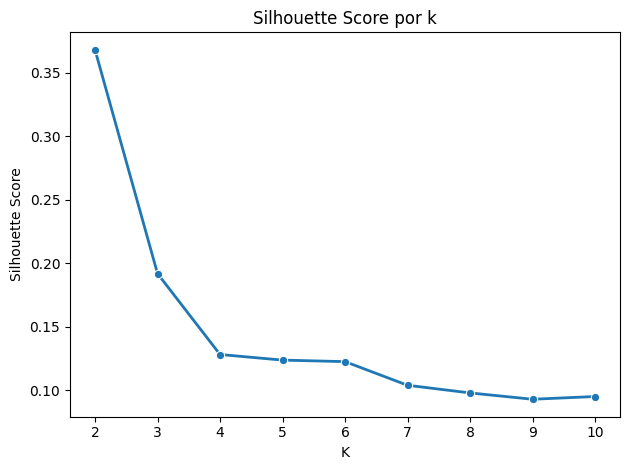

In [8]:
# Visualice Silhouette Score - weighted
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(weighted_data)
    sil_scores.append(silhouette_score(weighted_data, labels))

make_plot(
    plot_type="line",
    data=None,
    x_col=range(2, 11),
    y_col=sil_scores,
    title='Silhouette Score por k',
    xlabel="K",
    ylabel="Silhouette Score",
)
plt.show()

# Visualice Silhouette Score - ohe
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(ohe_data)
    sil_scores.append(silhouette_score(ohe_data, labels))

make_plot(
    plot_type="line",
    data=None,
    x_col=range(2, 11),
    y_col=sil_scores,
    title='Silhouette Score por k',
    xlabel="K",
    ylabel="Silhouette Score",
)
plt.show()

In [9]:
# See what features influence more on each principal component - weighted
loadings = pd.DataFrame(
    weighted_pca.components_.T[:, :3], columns=["PC1", "PC2", "PC3"], index=weighted_data.columns
)
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))
print(loadings["PC3"].abs().sort_values(ascending=False).head(5))

price                      0.502221
Steam Cloud                0.440856
recommendations            0.405347
Free To Play               0.397360
Full controller support    0.331779
Name: PC1, dtype: float32
Simulation                 0.507544
Action                     0.439920
Full controller support    0.409995
Strategy                   0.390094
Free To Play               0.245732
Name: PC2, dtype: float32
Multi-player    0.658645
Early Access    0.427242
Strategy        0.300723
Sports          0.205108
Action          0.204560
Name: PC3, dtype: float32


In [10]:
# See what features influence more on each principal component - ohe
loadings = pd.DataFrame(
    ohe_pca.components_.T[:, :3], columns=["PC1", "PC2", "PC3"], index=ohe_data.columns
)
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))
print(loadings["PC3"].abs().sort_values(ascending=False).head(5))

price                 0.692251
recommendations       0.673683
Steam Cloud           0.139204
Free To Play          0.127608
Steam Achievements    0.120109
Name: PC1, dtype: float32
recommendations       0.709140
price                 0.677683
Free To Play          0.165218
Steam Achievements    0.060208
Steam Cloud           0.048999
Name: PC2, dtype: float32
Action                     0.602371
Casual                     0.536468
Adventure                  0.422380
Simulation                 0.255865
Full controller support    0.204465
Name: PC3, dtype: float32


# First unsupervised model Training
### KMeans with weighed genres and categories.

In [11]:
# Train a KMEANS model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(weighted_data)
weighted_trained_pca_df["labels"] = kmeans_labels
fig = px.scatter_3d(
    weighted_trained_pca_df, x="PC1", y="PC2", z="PC3", color="labels", title="PCA 3D Visualization"
)
centroids_cords = weighted_trained_pca_df.groupby("labels")[["PC1", "PC2", "PC3"]].mean().reset_index()

# Add centroids
fig.add_trace(
    go.Scatter3d(
        x=centroids_cords["PC1"],
        y=centroids_cords["PC2"],
        z=centroids_cords["PC3"],
        mode="markers+text",
        marker=dict(
            size=12, color="black", symbol="diamond", line=dict(color="white", width=2)
        ),
        text=centroids_cords["labels"],
        textposition="top center",
        name="Centroides",
    )
)
fig.show()
fig.write_html(TRAINING_OUTPUT_PLOTS_PATH)

In [12]:
# Analyce kmeans labels output
scaler = joblib.load(FE_OUTPUT_SCALER_PATH)
centroids = kmeans.cluster_centers_

df_centroids = pd.DataFrame(
    centroids,
    columns=weighted_data.columns,
    index=[f"Cluster {i}" for i in range(kmeans.n_clusters)]
)

# See mean value columns for cluster
for i in range(kmeans.n_clusters):
    top_genres = df_centroids.loc[f"Cluster {i}", weighted_data.columns].sort_values(ascending=False)
    print(f"\n--- Cluster {i} ---")
    price_recommendations = [[df_centroids.loc[f'Cluster {i}', 'price'], df_centroids.loc[f'Cluster {i}', 'recommendations']]]
    print(f"Centroid mean price: {df_centroids.loc[f'Cluster {i}', 'price']}")
    print(f"Centroid mean recommendations: {df_centroids.loc[f'Cluster {i}', 'recommendations']}")
    print(f"Transformed price and recommendations: {scaler.inverse_transform(price_recommendations)}")
    print("Top genres/categories:")
    print(top_genres)


--- Cluster 0 ---
Centroid mean price: -0.13699324429035187
Centroid mean recommendations: -0.14036798477172852
Transformed price and recommendations: [[1.4439359  0.47707303]]
Top genres/categories:
Multi-player                  1.979262
Early Access                  1.554329
Action                        1.045579
Indie                         0.915168
Single-player                 0.831040
Casual                        0.749076
Strategy                      0.686073
Free To Play                  0.655199
Adventure                     0.610312
Simulation                    0.556152
Steam Achievements            0.534189
RPG                           0.515310
Partial Controller Support    0.457435
Full controller support       0.436476
Sports                        0.337234
Racing                        0.282371
Steam Cloud                   0.209111
price                        -0.136993
recommendations              -0.140368
Name: Cluster 0, dtype: float32

--- Cluster 1 ---
Centroi

# Second unsupervised model Training
### Kprototypes with genres and categories being booleans.

In [13]:
# Prepare data
numeric_cols = discrete_columns.columns
categorical_cols = np.concat([genres.columns, categories.columns])
#testdata = ohe_data.copy()

for c in categorical_cols:
    ohe_data[c] = ohe_data[c].astype('category')
for c in numeric_cols:
    ohe_data[c] = ohe_data[c].astype(float)

cat_indices = [ohe_data.columns.get_loc(c) for c in categorical_cols]
X_matrix = ohe_data.to_numpy()

k=2 -> cost=178295.22
k=3 -> cost=140487.57
k=4 -> cost=129293.43
k=5 -> cost=122665.66
k=6 -> cost=116516.01
k=7 -> cost=113031.29
k=8 -> cost=109336.38
k=9 -> cost=106484.73
k=10 -> cost=103499.22


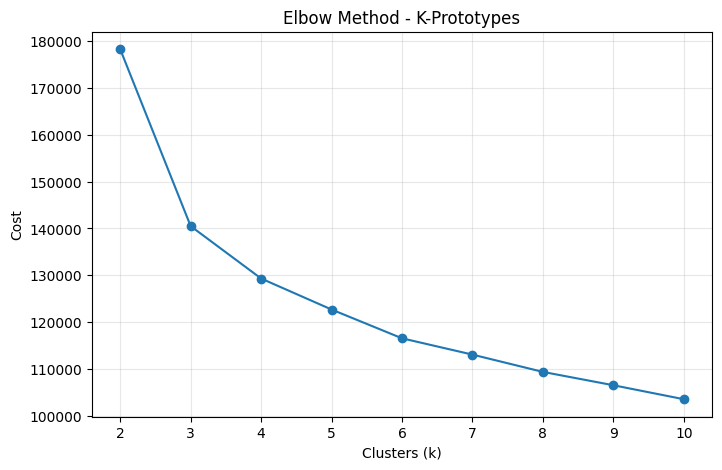

In [14]:
costs = []
K_range = range(2, 11)

for k in K_range:
    kproto_k = KPrototypes(
        n_clusters=k,
        init='Huang',
        n_init=10,        # bajo aquí para que el loop de búsqueda sea rápido
        random_state=42,
        verbose=0
    )
    kproto_k.fit_predict(X_matrix, categorical=cat_indices)
    costs.append(kproto_k.cost_)
    print(f"k={k} -> cost={kproto_k.cost_:.2f}")

plt.figure(figsize=(8,5))
plt.plot(list(K_range), costs, marker='o')
plt.xlabel('Clusters (k)')
plt.ylabel('Cost')
plt.title('Elbow Method - K-Prototypes')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Detect the optimal K value
from kneed import KneeLocator
kl = KneeLocator(list(K_range), costs, curve='convex', direction='decreasing')
k_optimal = kl.elbow
print("Suggested K value: ", k_optimal)

Suggested K value:  4


In [16]:
# Optimal training
kproto_final = KPrototypes(
    n_clusters=k_optimal, 
    init='Huang',
    n_init=20, # Final model, hight n_init 
    gamma=None,
    random_state=42,
    verbose=0
)

clusters = kproto_final.fit_predict(X_matrix, categorical=cat_indices)
ohe_data['cluster_kproto'] = clusters

print("Model final cost:", kproto_final.cost_)
print(ohe_data['cluster_kproto'].value_counts())

Model final cost: 129293.42927059808
cluster_kproto
1    22126
2    21681
3    12271
0     7917
Name: count, dtype: int64


[13.41595217  9.29718593  8.68199982]


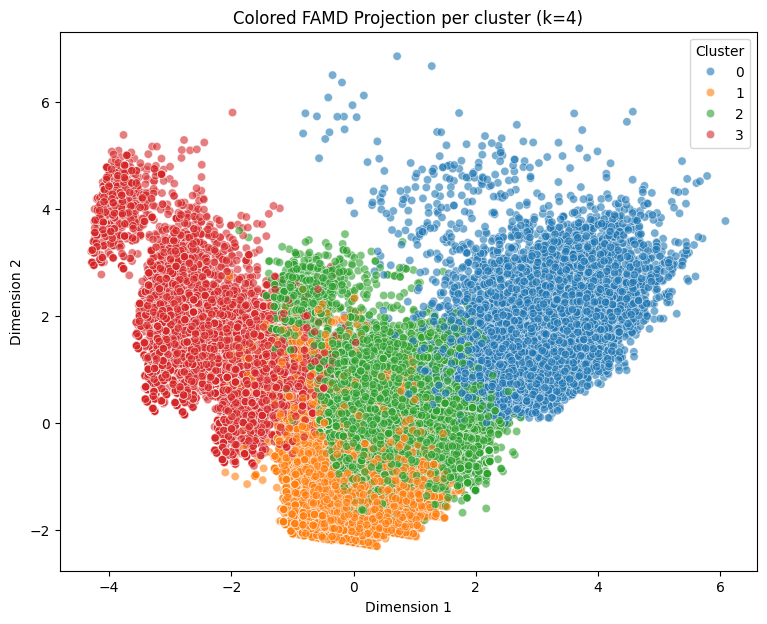

In [17]:
# FAMD visualization
X_famd = ohe_data.copy()
for c in categorical_cols:
    X_famd[c] = X_famd[c].astype('category')
for c in numeric_cols:
    X_famd[c] = X_famd[c].astype(float)

famd = prince.FAMD(n_components=3, n_iter=3, random_state=42)
famd = famd.fit(X_famd)

coords = famd.row_coordinates(X_famd)
coords.columns = ['Dim1', 'Dim2', 'Dim3']
coords['cluster'] = ohe_data['cluster_kproto'].values

print(famd.percentage_of_variance_)  # varianza explicada por cada dimensión

plt.figure(figsize=(9,7))
sns.scatterplot(data=coords, x='Dim1', y='Dim2', hue='cluster', palette='tab10', alpha=0.6)
plt.title(f'Colored FAMD Projection per cluster (k={4})')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(title='Cluster')
plt.show()

In [18]:
fig = px.scatter_3d(
    coords, x="Dim1", y="Dim2", z="Dim3", color="cluster", title="FAMD 3D Visualization"
)
centroids_cords_FAMD = coords.groupby("cluster")[["Dim1", "Dim2", "Dim3"]].mean().reset_index()

# Add centroids
fig.add_trace(
    go.Scatter3d(
        x=centroids_cords_FAMD["Dim1"],
        y=centroids_cords_FAMD["Dim2"],
        z=centroids_cords_FAMD["Dim3"],
        mode="markers+text",
        marker=dict(
            size=12, color="black", symbol="diamond", line=dict(color="white", width=2)
        ),
        text=centroids_cords_FAMD["cluster"],
        textposition="top center",
        name="Centroides",
    )
)
fig.show()